# Exploring melanocyte and pigmentation gene expression

The experimental model involves mouse strains with different coat color genetics (including C57BL/6, which carries a functional melanocortin pathway). This notebook explores whether melanocyte identity and melanin synthesis genes are detectable in the skin graft Xenium data, and how their expression varies across samples and conditions.

Two gene sets are examined:
- **Melanocyte core markers**: transcription factors and surface receptors that define melanocyte identity (e.g., *Mitf*, *Sox10*, *Kit*, *Pmel*, *Mlana*).
- **Melanin synthesis genes**: enzymes and transporters in the pigmentation pathway (e.g., *Tyr*, *Tyrp1*, *Dct*, *Slc45a2*).

Expression is visualized as dotplots per sample to assess whether pigmentation differences between genotypes are reflected at the transcriptional level.

In [43]:
import scanpy as sc
import matplotlib.pyplot as plt
sc.set_figure_params(figsize=(3, 3), frameon=False)
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [44]:
adata = sc.read_h5ad('../../data/talbot_xenium.h5ad')
adata = adata[adata.obs.tissue == 'skin']

In [45]:
core_melanin_genes = ["Tyr", "Tyrp1", "Dct", "Mc1r"]

melanocyte_core present: ['Mitf', 'Sox10', 'Kit', 'Ednrb']
melanin_synthesis present: ['Tyr', 'Tyrp1', 'Dct', 'Slc45a2', 'Oca2']


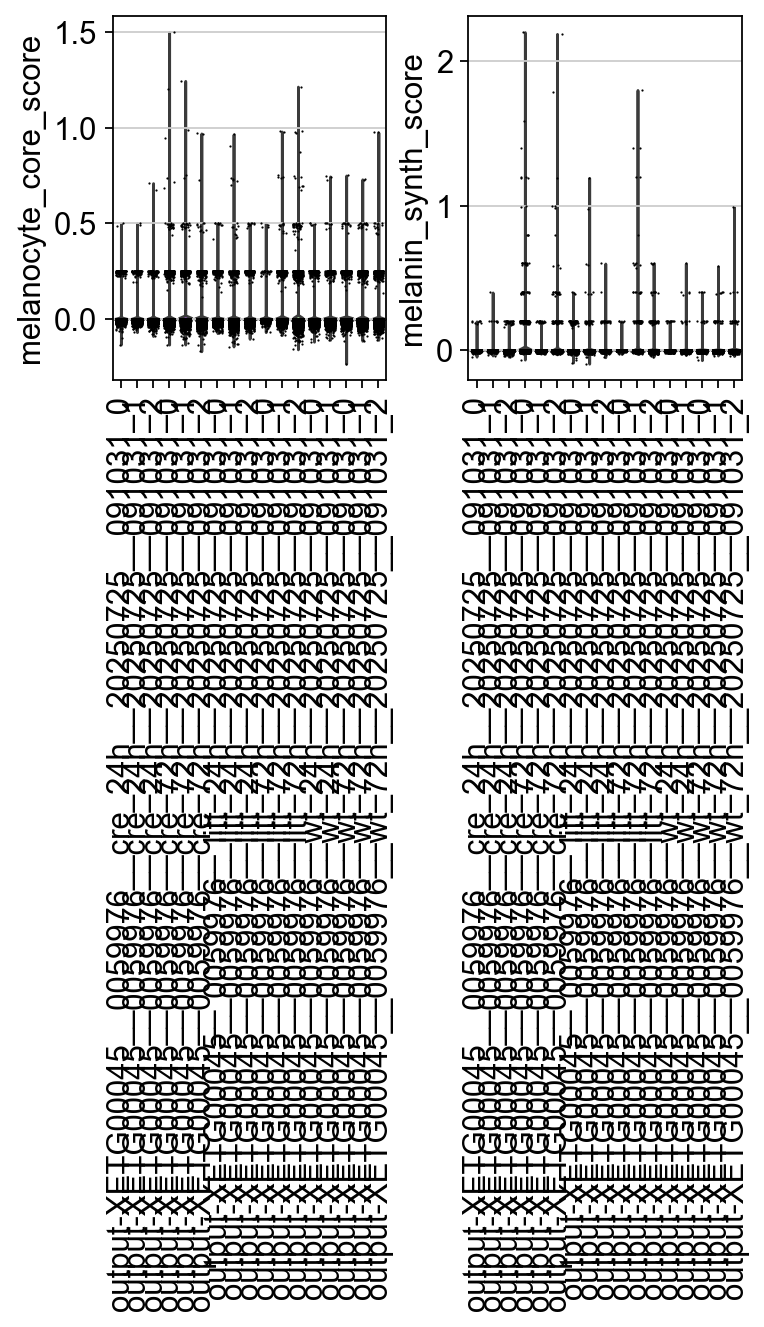

In [48]:

# Candidate gene sets
melanocyte_core = ["Mitf","Sox10","Kit","Ednrb","Pmel","Mlana"]
melanin_synthesis = ["Tyr","Tyrp1","Dct","Slc45a2","Slc24a5","Oca2"]

# Keep only genes that are in your panel
melanocyte_core = [g for g in melanocyte_core if g in adata.var_names]
melanin_synthesis = [g for g in melanin_synthesis if g in adata.var_names]

print("melanocyte_core present:", melanocyte_core)
print("melanin_synthesis present:", melanin_synthesis)

# Compute scores (works on counts or log1p; use what you have)
sc.tl.score_genes(adata, melanocyte_core, score_name="melanocyte_core_score", use_raw=False)
sc.tl.score_genes(adata, melanin_synthesis, score_name="melanin_synth_score", use_raw=False)

# Quick view by condition if you have it in obs (e.g., 'condition')
group = "sample_id" if "sample_id" in adata.obs.columns else None

sc.pl.violin(adata, keys=["melanocyte_core_score","melanin_synth_score"], groupby=group, jitter=0.3, rotation=90)

In [50]:
sc.tl.dendrogram(adata, groupby = 'sample_id')

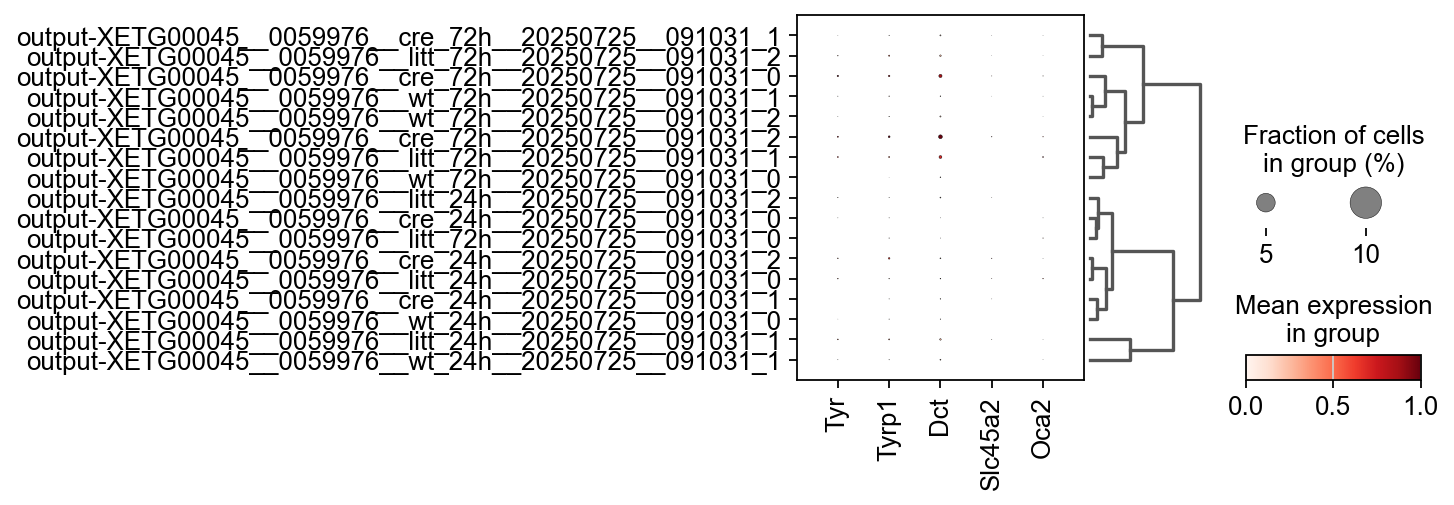

In [52]:
sc.pl.dotplot(
        adata,
        var_names=melanin_synthesis,
        groupby="sample_id",
        standard_scale="var",
        #dot_max=0.5,
        #dot_min=0.05,
        color_map="Reds",
        dendrogram=True,
        figsize=(5, 3),
        #categories_order=['Ctrl','Early','Peak','Late'],
    )